In [1]:
import warnings
warnings.simplefilter('ignore')
import os
import glob
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt
import sunpy
from sunpy.map import Map
from astropy import units as u
from sunpy.time import parse_time
from astropy.coordinates import SkyCoord
from aiapy.calibrate.prep import correct_degradation
from aiapy.calibrate import register, update_pointing
from astropy.visualization import ImageNormalize, SqrtStretch
from tqdm import tqdm

data_dir = '/home/mnedal/data'

In [2]:
date = '2025-10-06'
channel = 304
year, month, day = date.split('-')
print(year, month, day)

2025 10 06


In [4]:
files = sorted(glob.glob(f'{data_dir}/AIA/{channel}A/highres/lv15/aia.lev15.{channel}A_{year}_{month}_{day}T*_lev15*.fits'))
print(len(files), *files[:3], sep='\n')

600
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_05.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_17.13Z.image_lev15.fits
/home/mnedal/data/AIA/304A/highres/lv15/aia.lev15.304A_2025_10_06T08_30_29.13Z.image_lev15.fits


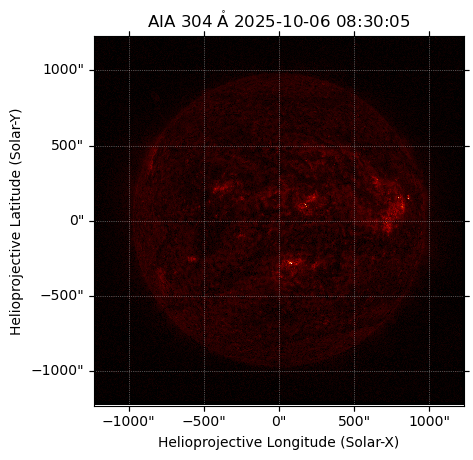

In [5]:
sequence = sunpy.map.Map(files, sequence=True)

fig = plt.figure()
ax = fig.add_subplot(projection=sequence.maps[0])
ani = sequence.plot(axes=ax, norm=ImageNormalize(vmin=0, vmax=5e3, stretch=SqrtStretch()))
plt.show()

In [6]:
for m in sequence:
    m.plot_settings['norm'] = ImageNormalize(vmin=-10, vmax=5e2, stretch=SqrtStretch())

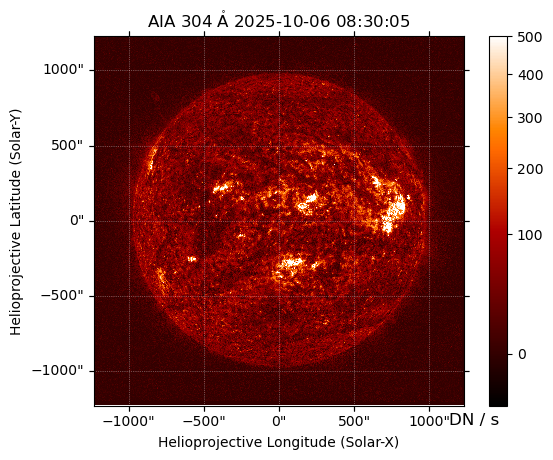

In [7]:
sequence.maps[0].peek()

In [15]:
# Find the frame index at a given datetime
target = parse_time('2025-10-06T09:22:53')

idx = np.argmin([abs(m.date - target) for m in sequence.maps])
print(idx)
aia = sequence[idx]

264


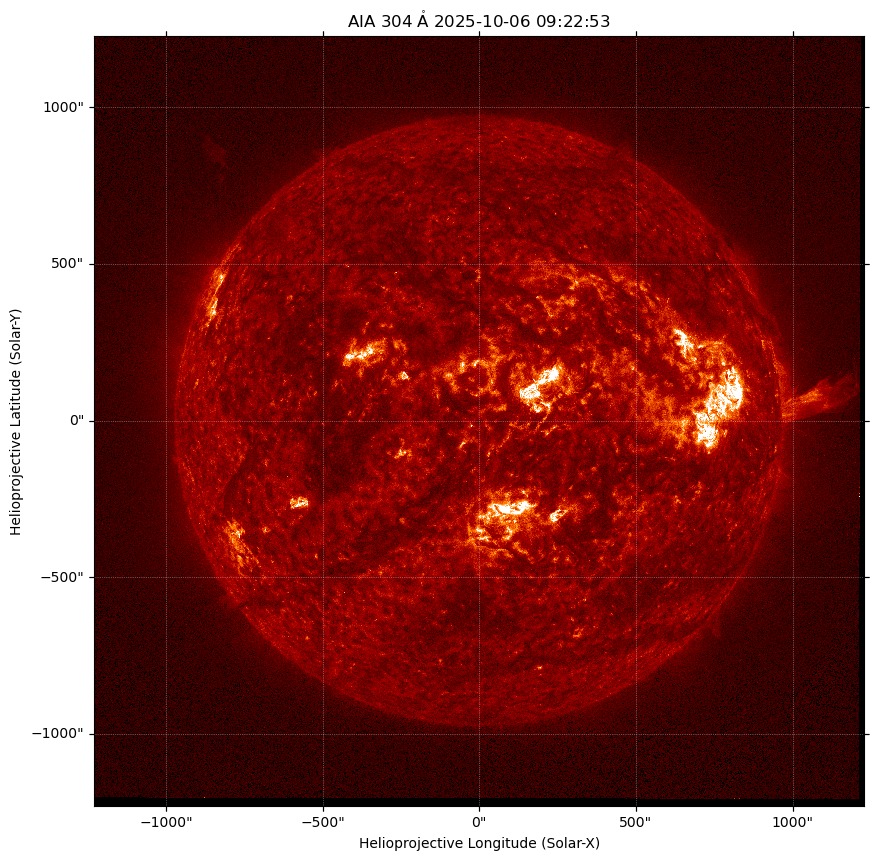

In [16]:
fig = plt.figure(figsize=[10,10])
ax  = fig.add_subplot(projection=aia)
aia.plot(axes=ax)
# ax.grid(False)
plt.show()

In [17]:
# with tqdm(total=len(files), desc=f'Export AIA maps ...') as pbar:
#     for m in sequence:
#         fig = plt.figure(figsize=[7,7])
#         ax  = fig.add_subplot(projection=m)
#         m.plot(axes=ax)
#         ax.grid(False)
#         fig.savefig(f"{data_dir}/AIA/{channel}A/highres/lv15/submaps/aia_{channel}A_lv15_FullDisk_{m.meta['date-obs'][:-3]}.png", format='png', bbox_inches='tight')
#         plt.close()
#         pbar.update(1)

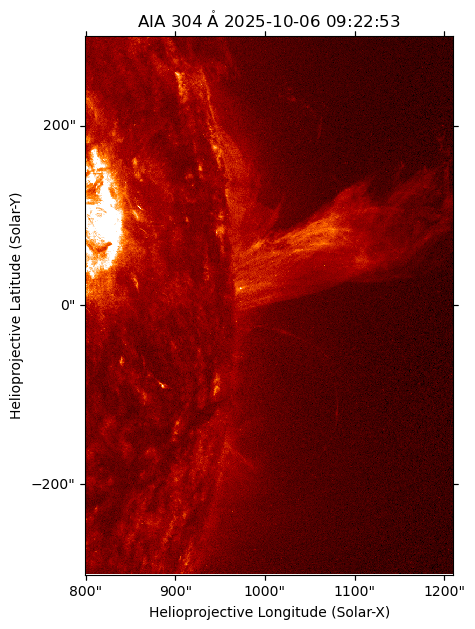

In [18]:
# West limb region
ROI_TOP    = 300    # arcsec
ROI_RIGHT  = 1210   # arcsec
ROI_BOTTOM = -300   # arcsec
ROI_LEFT   = 800    # arcsec

# # Central region
# ROI_TOP    =  400   # arcsec
# ROI_RIGHT  =  500   # arcsec
# ROI_BOTTOM = -200   # arcsec
# ROI_LEFT   = -120   # arcsec

top_right   = SkyCoord(ROI_RIGHT*u.arcsec, ROI_TOP*u.arcsec, frame=aia.coordinate_frame)
bottom_left = SkyCoord(ROI_LEFT*u.arcsec, ROI_BOTTOM*u.arcsec, frame=aia.coordinate_frame)
aia_submap  = aia.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=[7,7])
ax  = fig.add_subplot(projection=aia_submap)
aia_submap.plot(axes=ax)
ax.grid(False)
plt.show()

In [111]:
os.makedirs(f'{data_dir}/AIA/{channel}A/highres/lv15/submaps', exist_ok=True)

In [19]:
# region = 1

# with tqdm(total=len(files), desc=f'Export AIA submaps ...') as pbar:
#     for m in sequence:
#         if region==1:
#             top_right   = SkyCoord(400*u.arcsec, 300*u.arcsec, frame=m.coordinate_frame)
#             bottom_left = SkyCoord(30*u.arcsec, -70*u.arcsec, frame=m.coordinate_frame)
#         elif region==2:
#             top_right   = SkyCoord(1230*u.arcsec, 300*u.arcsec, frame=m.coordinate_frame)
#             bottom_left = SkyCoord(800*u.arcsec, -350*u.arcsec, frame=m.coordinate_frame)
#         else:
#             break

#         m_submap  = m.submap(bottom_left, top_right=top_right)
        
#         fig = plt.figure(figsize=[7,7])
#         ax  = fig.add_subplot(projection=m_submap)
#         m_submap.plot(axes=ax)
#         ax.grid(False)
#         fig.savefig(f"{data_dir}/AIA/{channel}A/highres/lv15/submaps/aia_{channel}A_lv15_Reg{region}_{m.meta['date-obs'][:-3]}.png", format='png', bbox_inches='tight')
#         plt.close()
#         pbar.update(1)